# EDA of Titanic Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.shape
# This Dataset contains the 891 rows and 12 columns

(891, 12)

# Steps In EDA
### Lable columns -> Univariate Analysis -> Bivariate Analysis -> Multivariate Analysis -> Feature Engineering -> Outlier detection -> Imputation of Missing values

### Column Types
- `Numerical` - Age, Fare, PassengerId, SibSp, Parch
- `Categorical` - Survived, Pclass, Sex, Embarked
- `Mixed` - Name, Ticket, Cabin

In [5]:
df.columns
# Following 13 are the columns from this dataset

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Steps of doing Univariate Analysis on Numerical columns

- **Descriptive Statistics**: Compute basic summary statistics for the column, such as mean, median, mode, standard deviation, range, and quartiles. These statistics give a general understanding of the distribution of the data and can help identify skewness or outliers.

- **Visualizations**: Create visualizations to explore the distribution of the data. Some common visualizations for numerical data include histograms, box plots, and density plots. These visualizations provide a visual representation of the distribution of the data and can help identify skewness an outliers.

- **Identifying Outliers**: Identify and examine any outliers in the data. Outliers can be identified using visualizations. It is important to determine whether the outliers are due to measurement errors, data entry errors, or legitimate differences in the data, and to decide whether to include or exclude them from the analysis.

- **Skewness**: Check for skewness in the data and consider transforming the data or using robust statistical methods that are less sensitive to skewness, if necessary.

- **Conclusion**: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.


In [7]:
df.isnull().sum()
# Column Age and Cabin has the highest number of missing values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Univariate Analysis on Numerical Column 

## Age 
`Conclusion :`
- Age is Almost Normally Distributed
- There are some Outliers
- Approx 20% values are Missing

In [8]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

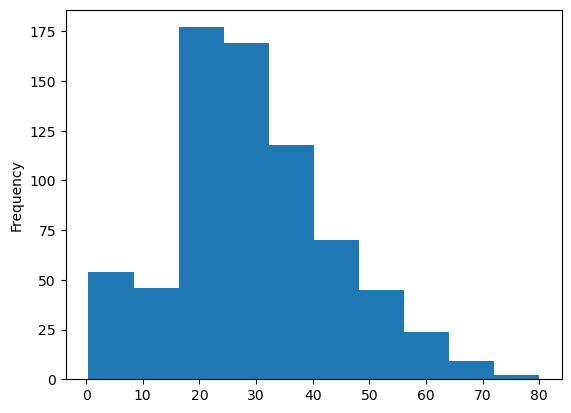

In [9]:
df['Age'].plot(kind='hist')

# number of peoples Travelling are more having the age between 20 to 40 

<Axes: ylabel='Density'>

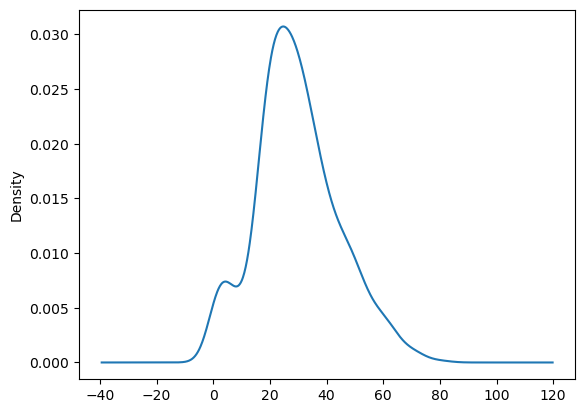

In [10]:
df['Age'].plot(kind='kde')

# graph is slightlly positively skewed so we can call it as almost Noramallly Distributed

In [11]:
df['Age'].skew()  
# The value of skewness is greater than 0, thus it not the Normally distributed

np.float64(0.38910778230082704)

<Axes: >

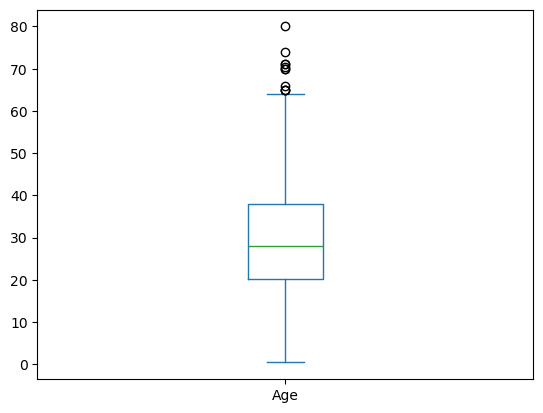

In [12]:
df['Age'].plot(kind='box')
# 

In [13]:
df[df['Age']>65]
# This are the 8 persons having the age greater than the 65(Outliers)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [14]:
df['Age'].isnull().sum()/len(df['Age'])*100
# Approx 20% values are Missing

np.float64(19.865319865319865)

## Fare 
`Conclusion:-`
- Fare is Highly(Positively) Skewed.
- Fare has Greater number of outliers.
- Fare column actually conntains the group fare not the indivisual fare.
- We need to create the new column called indivisual fare.

In [15]:
# Fare

df['Fare'].describe() 

# some people travels free without spending money 
# some people travels by Paying 512 

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [16]:
df['Fare'].isnull().sum()
# There is no Missing Values

np.int64(0)

<Axes: ylabel='Frequency'>

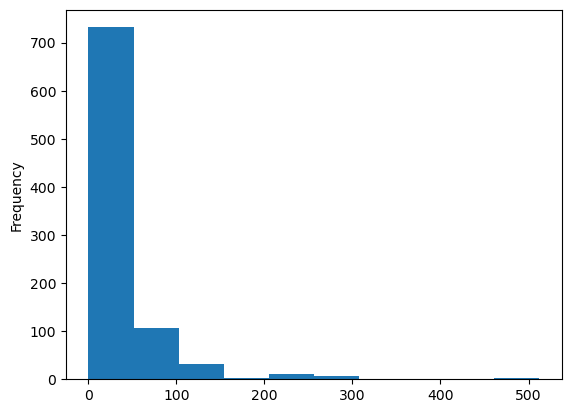

In [17]:
df['Fare'].plot(kind='hist')

<Axes: ylabel='Density'>

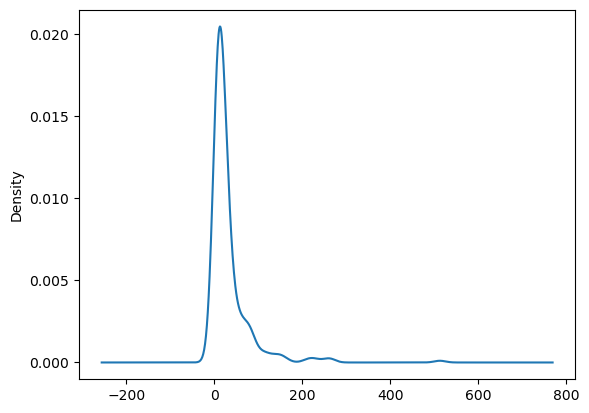

In [18]:
df['Fare'].plot(kind='kde')

In [19]:
df['Fare'].skew()
# fare is positively skewed so, Fare is Not Normally Distributed

np.float64(4.787316519674893)

<Axes: >

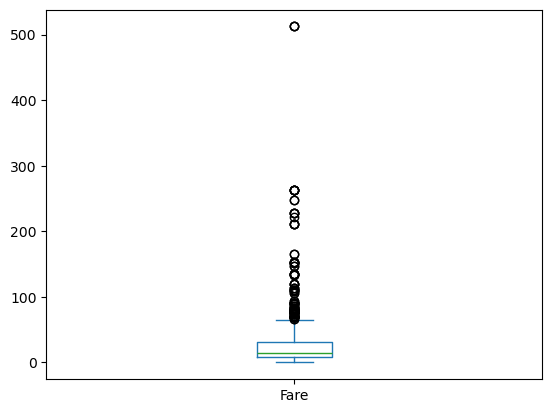

In [20]:
df['Fare'].plot(kind='box')
# Fare has greater number of outliers

In [21]:
df[df['Fare']>300]

# It is seen that there are 3 passengers who has Fare 512 and there Tickets are also same.
# From this it seen that the this Fare is the total Fare paid by the Family (group fare)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


# Univariate analysis on Categorical Column

## Survived
`Conclusion :-`
- Accident is more Deadly as 60.6% passengers are died and only 38.2% passengers are Survived.

In [22]:
df['Survived'].value_counts()

# 342 Survived
# 549 died

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived'>

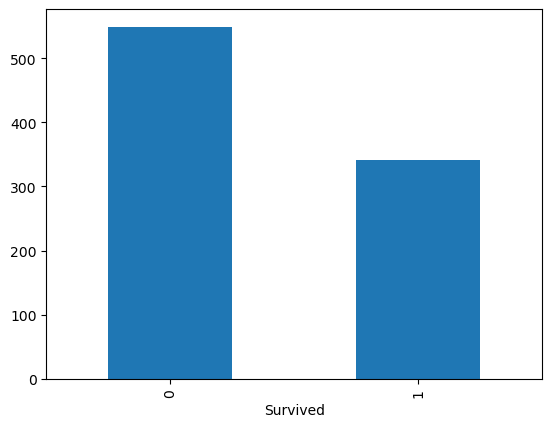

In [23]:
df['Survived'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

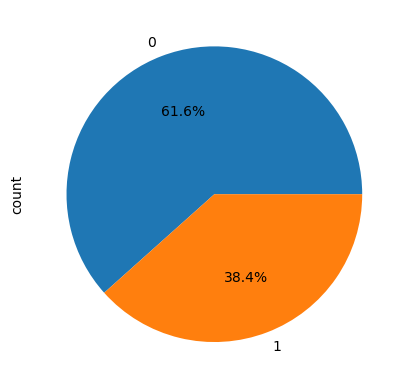

In [24]:
df['Survived'].value_counts().plot(kind='pie', autopct = '%0.1f%%')

# 61.6% passenger Died
# 38.4 % passenger survived

In [25]:
 df['Survived'].isnull().sum()

# there is No Missing values

np.int64(0)

## Pclass
`Conclusion :-`
- More People travelled in Pclass 3 then in Pclass 1 then Pclass 2

In [26]:
df['Pclass'].isnull().sum()

np.int64(0)

In [27]:
df['Pclass'].unique()

array([3, 1, 2])

In [28]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: xlabel='Pclass'>

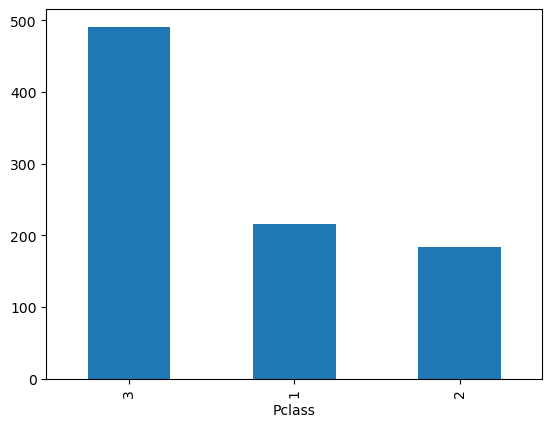

In [29]:
df['Pclass'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

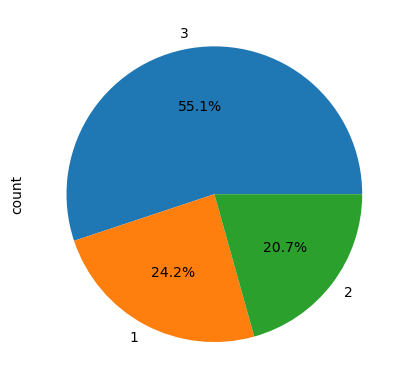

In [30]:
df['Pclass'].value_counts().plot(kind='pie',autopct='%0.1f%%')

## Sex
`Conclusion`
- Passenger contains the maximum Males than Females

In [31]:
df['Sex'].isnull().sum()

np.int64(0)

In [32]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Sex'>

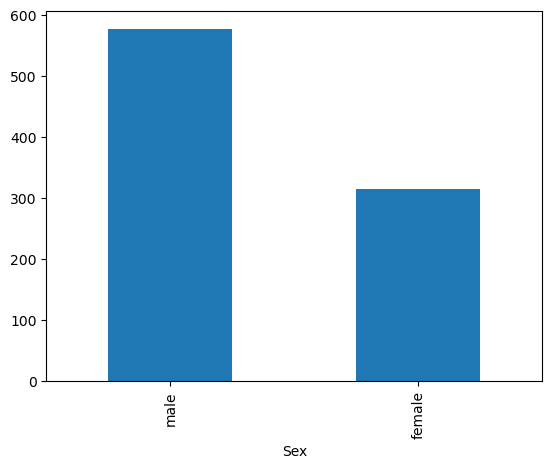

In [33]:
df['Sex'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

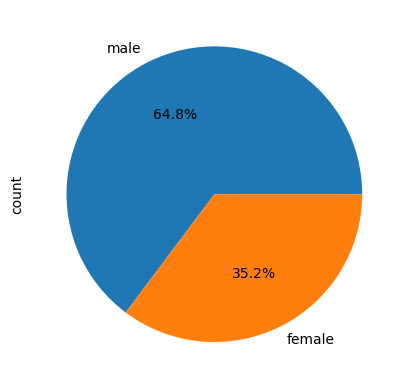

In [34]:
df['Sex'].value_counts().plot(kind='pie', autopct='%0.1f%%')

## Embarked
`Conclusion`
- It is seen that from S Large number of peopple arrived than C and then Q

In [35]:
df['Embarked'].isnull().sum()

np.int64(2)

In [36]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: xlabel='Embarked'>

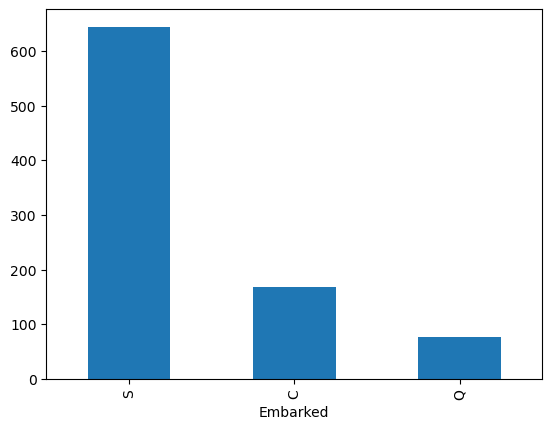

In [37]:
df['Embarked'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

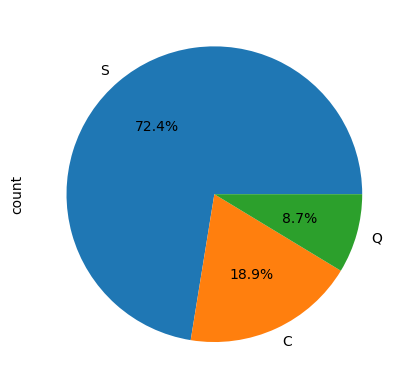

In [38]:
df['Embarked'].value_counts().plot(kind='pie', autopct='%0.1f%%')

## SibSp & Parch
`Conclusion`
- Parch and Sibsp column merged to form new column family_size.
- we can also create a new column called is_alone.

In [39]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

<Axes: xlabel='SibSp'>

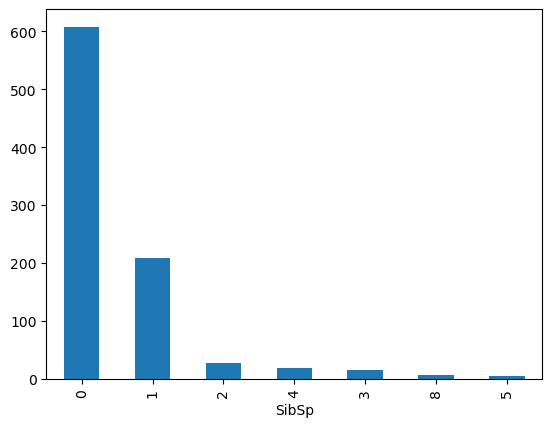

In [40]:
df['SibSp'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

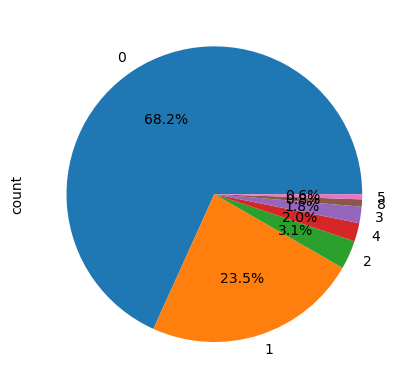

In [41]:
df['SibSp'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [42]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

<Axes: xlabel='Parch'>

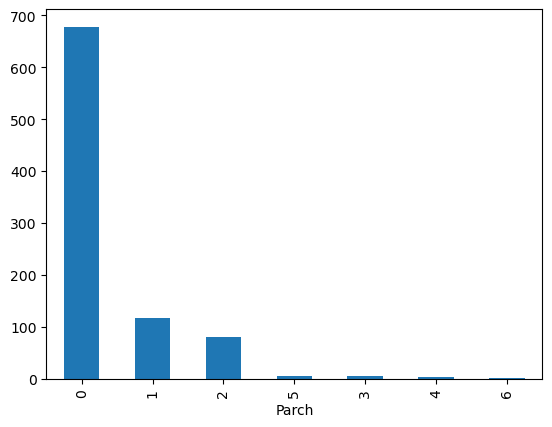

In [43]:
df['Parch'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

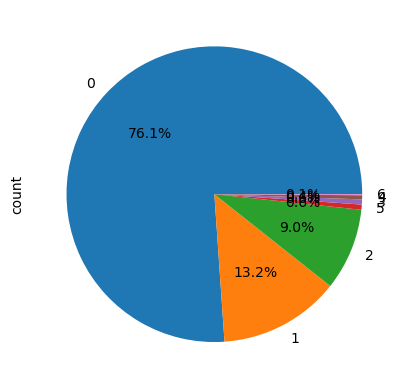

In [44]:
df['Parch'].value_counts().plot(kind='pie',autopct='%0.1f%%')

# Bivariate Analysis 

## Survived vs Pclass (Categorical vs Categorical)

In [45]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [46]:
pd.crosstab(df['Survived'], df['Pclass'])

Pclass,1,2,3
Survived,,,
0,80,97,372
1,136,87,119


In [47]:
pd.crosstab(df['Survived'], df['Pclass'], normalize = 'columns')*100

# In Pclass 3 the % of death is higher than other class 

Pclass,1,2,3
Survived,,,
0,37.037037,52.717391,75.763747
1,62.962963,47.282609,24.236253


<Axes: xlabel='Pclass', ylabel='Survived'>

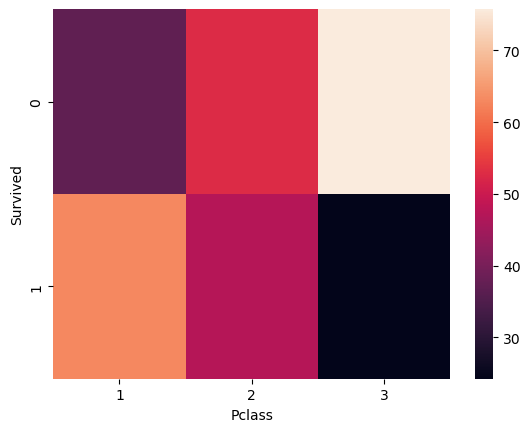

In [48]:
sns.heatmap(pd.crosstab(df['Survived'], df['Pclass'], normalize = 'columns')*100)

## Survived vs Sex

In [49]:
pd.crosstab(df['Survived'], df['Sex'], normalize = 'columns')*100

# Death rate of Male is Higher that the Female

Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


<Axes: xlabel='Sex', ylabel='Survived'>

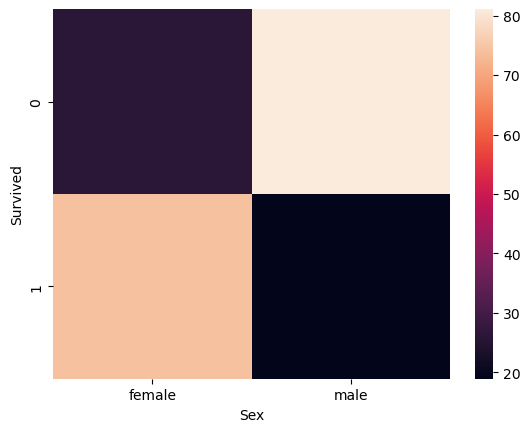

In [50]:
sns.heatmap(pd.crosstab(df['Survived'], df['Sex'], normalize = 'columns')*100)

## Survived vs Pclass

In [51]:
pd.crosstab(df['Survived'], df['Pclass'], normalize = 'columns')*100

Pclass,1,2,3
Survived,,,
0,37.037037,52.717391,75.763747
1,62.962963,47.282609,24.236253


<Axes: xlabel='Pclass', ylabel='Survived'>

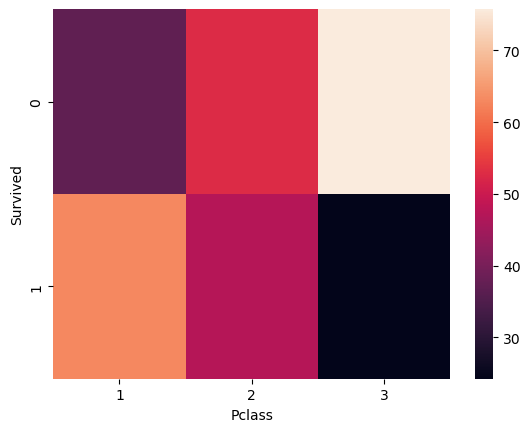

In [52]:
sns.heatmap(pd.crosstab(df['Survived'], df['Pclass'], normalize = 'columns')*100)

## Survived vs Embarked 

In [53]:
pd.crosstab(df['Survived'], df['Embarked'], normalize = 'columns')*100

Embarked,C,Q,S
Survived,,,
0,44.642857,61.038961,66.304348
1,55.357143,38.961039,33.695652


<Axes: xlabel='Age', ylabel='Survived'>

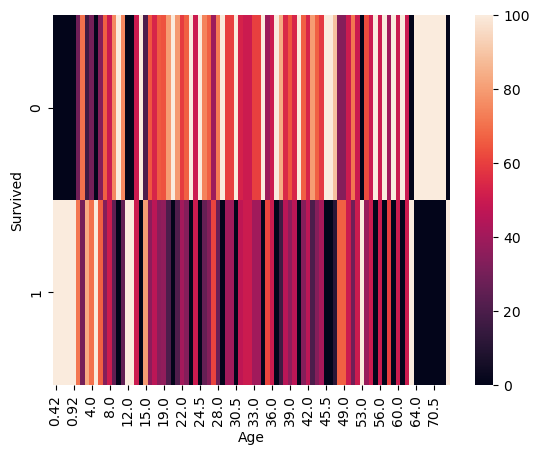

In [54]:
sns.heatmap(pd.crosstab(df['Survived'], df['Age'], normalize = 'columns')*100)

## Sex vs Embarked

In [55]:
pd.crosstab(df['Sex'], df['Embarked'], normalize = 'columns')*100

Embarked,C,Q,S
Sex,,,
female,43.452381,46.753247,31.521739
male,56.547619,53.246753,68.478261


In [56]:
pd.crosstab(df['Pclass'], df['Embarked'], normalize = 'columns')*100

Embarked,C,Q,S
Pclass,,,
1,50.595238,2.597403,19.720497
2,10.119048,3.896104,25.465839
3,39.285714,93.506494,54.813665


## Survived vs Age (Categorical vs Numerical)

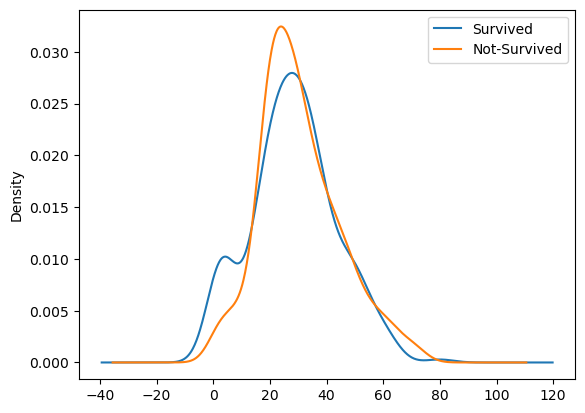

In [57]:
df[df['Survived']==1]['Age'].plot(kind='kde', label="Survived")
df[df['Survived']==0]['Age'].plot(kind='kde', label="Not-Survived")

plt.legend()
plt.show()

# Surviaval chances of childrens (Age -> 0 to 5) is greater
# And age between 20 to 30 less chance of survival
# Again srvival chance of 40 to 60 is higher

## Feature Engineering
### `Fare`:
- This column contains the fare for the total family.
- Means the fare paid for the whole family is written in front of each of the family member.
- need to do feature engineering to calculate the fare paid by the particular indivisual.
- By performing Feature Engineering we create new Colummn as IndivisualFare.

### `IndivisualFare`:
`Conclusion`:
- There Are Outliers in this columns

In [58]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [59]:
df[df['SibSp']==8]

# It is seen that from SibSp+Parch = 10 with him total 11 family member But here only 7 members data is present with same ticket and same Sir name.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [60]:
df[df['Ticket']=='CA. 2343']

# Only 7 present 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [61]:
df[df['Name'].str.contains('Sage')]

# Exclude index 641 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
641,642,1,1,"Sagesser, Mlle. Emma",female,24.0,0,0,PC 17477,69.30,B35,C
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


####  So from above operations it is conclude that other 4 passengers are get another/different Ticket or tha Adta is Missing

#### Data of another Passengers May present inside the test dataset

In [62]:
df1 = pd.read_csv('test.csv')
df1

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [63]:
df1[df1['Ticket']=='CA. 2343']

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
188,1080,3,"Sage, Miss. Ada",female,NaN,8,2,CA. 2343,69.55,NaN,S
342,1234,3,"Sage, Mr. John George",male,NaN,1,9,CA. 2343,69.55,NaN,S
360,1252,3,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,NaN,S
365,1257,3,"Sage, Mrs. John (Annie Bullen)",female,NaN,1,9,CA. 2343,69.55,NaN,S


In [64]:
# now we get the all passengers data 

In [65]:
df['indivisualFare'] = df['Fare']/(df['SibSp']+df['Parch']+1)
df

# Now we get indivisual fare

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,indivisualFare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,13.00000
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,30.00000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,5.86250
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,30.00000


<Axes: >

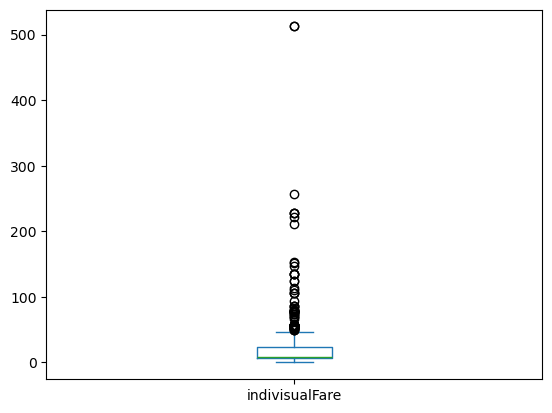

In [66]:
df['indivisualFare'].plot(kind='box')

### `SibSp And Parch`:
- There is no need to create the separete columns for the SibSp and the Parch
- By performing Feature Engineering we create a new Column Called FamilySize.
- We also Create the family_type column based on the number of member

`Conclusion`:
- It is seen that if passnenger is alone the Survival chance is less
- If the family size is Large then the Survival Chance is very less
- If the family size is small then the survival chnace is higher than the death.

In [74]:
df['FamilySize'] = df['SibSp']+df['Parch']+1
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,indivisualFare,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,13.00000,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,30.00000,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,5.86250,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,30.00000,1


In [73]:
# family_typa:
# 1 -> alone
# 2 - 4 -> small
# >5 -> large

def transform_family_size(num):
    if num == 1:
        return 'alone'
    elif num>=2 and num<=4:
        return 'small'
    else:
        return 'large'


In [83]:
df['FamilyType'] = df['FamilySize'].apply(transform_family_size)

In [84]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,indivisualFare,FamilySize,FamilyType
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2,small
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,small
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1,alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,small
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1,alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,13.00000,1,alone
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,30.00000,1,alone
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,5.86250,4,small
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,30.00000,1,alone


In [103]:
pd.crosstab(df['Survived'], df['FamilyType'],normalize='columns')*100

FamilyType,alone,large,small
Survived,,,
0,69.646182,85.106383,42.123288
1,30.353818,14.893617,57.876712


### `Name`:
- We perform the feature Engineering on the column Name to separate the sirname and names
- By spliting the surnames we can identify the families


- We can also split the title from the name column to categories the passengers based on the title like, Mr, Miss, Mrs.etc.
  

In [113]:
df['Surname'] = df['Name'].str.split(',').str.get(0)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,indivisualFare,FamilySize,FamilyType,Surname
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2,small,Braund
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,small,Cumings
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1,alone,Heikkinen
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,small,Futrelle
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1,alone,Allen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,13.00000,1,alone,Montvila
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,30.00000,1,alone,Graham
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,5.86250,4,small,Johnston
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,30.00000,1,alone,Behr


In [132]:
df['title'] = df['Name'].str.split('.').str.get(0).str.split(',').str.get(1).str.strip()

In [134]:
df['title'].value_counts()

title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [140]:
df['title'] = df['title'].replace(['Rev','Dr','Col','Mlle','Major','Ms','Mme','Don','Lady','Sir','Capt','the Countess','Jonkheer'], 'other')

In [141]:
df['title'].value_counts()

title
Mr        517
Miss      182
Mrs       125
Master     40
other      27
Name: count, dtype: int64

In [147]:
pd.crosstab(df['Survived'],df['title'],normalize='columns')*100

title,Master,Miss,Mr,Mrs,other
Survived,,,,,
0,42.5,30.21978,84.332689,20.8,55.555556
1,57.5,69.78022,15.667311,79.2,44.444444



### `Cabin`

- This column contains the more number of missing values

In [163]:
df['Cabin'].isnull().sum()/len(df['Cabin'])*100

# 77% values are missing in this column

np.float64(77.10437710437711)

In [165]:
df['Cabin'].fillna('M', inplace=True)
df['Cabin']

0         M
1       C85
2         M
3      C123
4         M
       ... 
886       M
887     B42
888       M
889    C148
890       M
Name: Cabin, Length: 891, dtype: object

In [166]:
df['Cabin'].value_counts()

Cabin
M              687
G6               4
C23 C25 C27      4
B96 B98          4
F2               3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

In [170]:
df['Deck'] = df['Cabin'].str[0]

In [172]:
df['Deck']

0      M
1      C
2      M
3      C
4      M
      ..
886    M
887    B
888    M
889    C
890    M
Name: Deck, Length: 891, dtype: object

In [173]:
df['Deck'].value_counts()

Deck
M    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [176]:
pd.crosstab(df['Deck'], df['Pclass'])

Pclass,1,2,3
Deck,,,
A,15,0,0
B,47,0,0
C,59,0,0
D,29,4,0
E,25,4,3
F,0,8,5
G,0,0,4
M,40,168,479
T,1,0,0


<Axes: xlabel='Deck'>

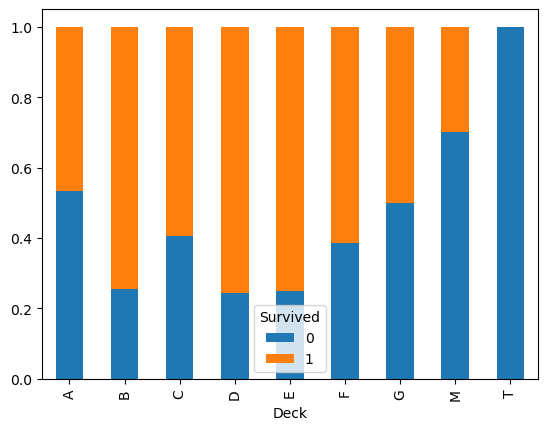

In [184]:
pd.crosstab(df['Deck'], df['Survived'],normalize='index').plot(kind='bar', stacked = True)

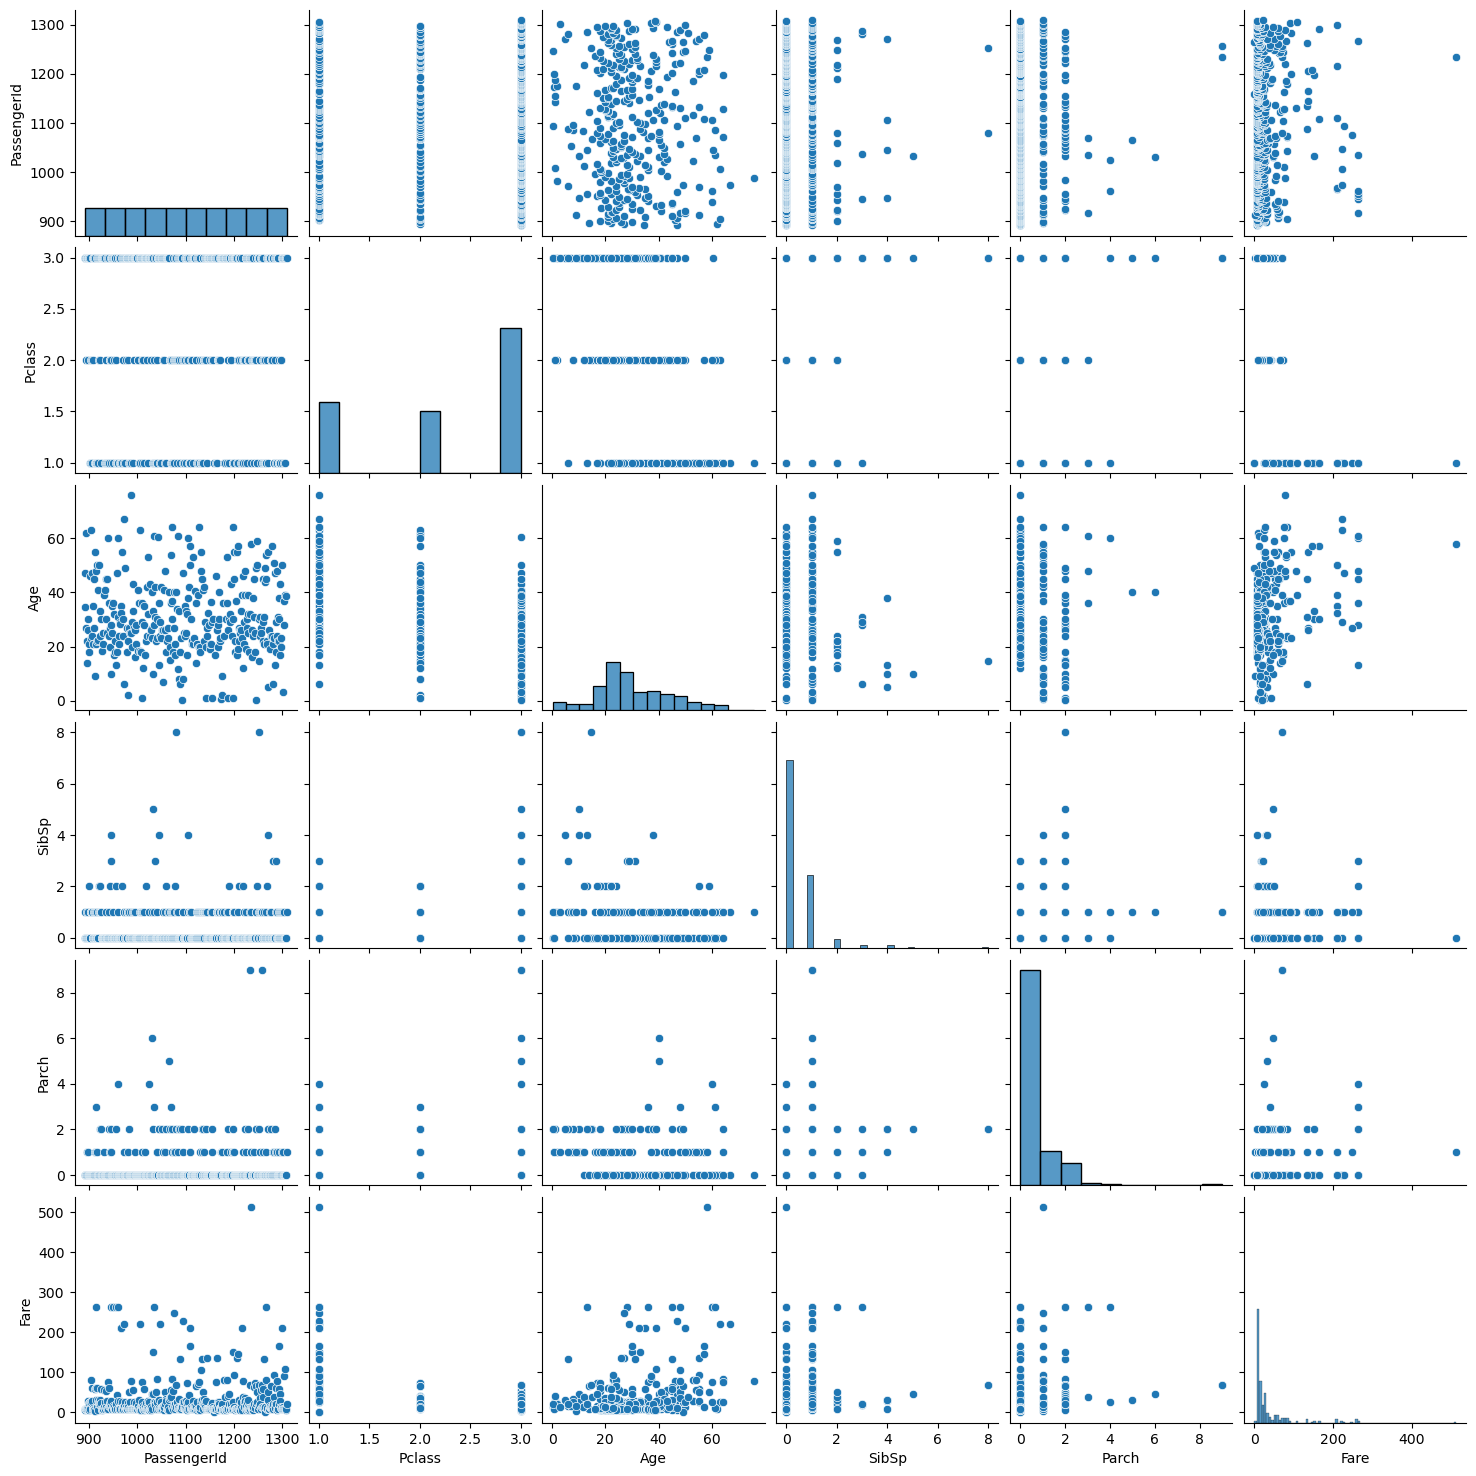

In [196]:
sns.pairplot(df1)